# IEEE-CIS Fraud Detection — EDA

## 0. Imports and settings

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (10, 4)

RAW_DIR = Path("../data/raw")
assert RAW_DIR.exists(), f"{RAW_DIR.resolve()} not found"

## 1. Data loading and first inspection

### 1.1 Read the CSVs

In [2]:
df_txn = pd.read_csv(RAW_DIR / "train_transaction.csv")
df_id = pd.read_csv(RAW_DIR / "train_identity.csv")

print(f"train_transaction shape : {df_txn.shape}")
print(f"train_identity shape    : {df_id.shape}")
print(f"[column count] transaction={df_txn.shape[1]}, identity={df_id.shape[1]}")

train_transaction shape : (590540, 394)
train_identity shape    : (144233, 41)
[column count] transaction=394, identity=41


### 1.2 Head + dtypes

In [3]:
df_txn.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,...,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,...,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,NaN,NaN,NaN,M0,...,1.0,1.0,1.0,1.0,38.0,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,50.0,1758.0,925.0,0.0,354.0,0.0,135.0,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df_id.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,NaN,100.0,NotFound,49.0,-300.0,New,NotFound,166.0,NaN,621.0,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,iOS 11.1.2,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,52.0,NaN,Found,Found,121.0,NaN,410.0,142.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,NaN,100.0,NotFound,52.0,NaN,New,NotFound,225.0,NaN,176.0,507.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,NaN,-300.0,Found,Found,166.0,15.0,529.0,575.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,Mac OS X 10_11_6,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [5]:
dtype_summary = (
    df_txn.dtypes.value_counts().rename("transaction")
    .to_frame()
    .join(df_id.dtypes.value_counts().rename("identity"), how="outer")
    .fillna(0)
    .astype(int)
)
dtype_summary

,transaction,identity
int64,4,1
float64,376,23
object,14,17


### 1.3 `isFraud` distribution

The target variable. Measure the magnitude of the class imbalance used for computing `scale_pos_weight`.

In [6]:
fraud_counts = df_txn["isFraud"].value_counts().sort_index()
fraud_rate = df_txn["isFraud"].mean()
scale_pos_weight = fraud_counts[0] / fraud_counts[1]

print(f"isFraud=0 (legit) : {fraud_counts[0]:>7,}")
print(f"isFraud=1 (fraud) : {fraud_counts[1]:>7,}")
print(f"fraud rate        : {fraud_rate:.4%}")
print(f"scale_pos_weight  : {scale_pos_weight:.2f}")

isFraud=0 (legit) : 569,877
isFraud=1 (fraud) :  20,663
fraud rate        : 3.4990%
scale_pos_weight  : 27.58


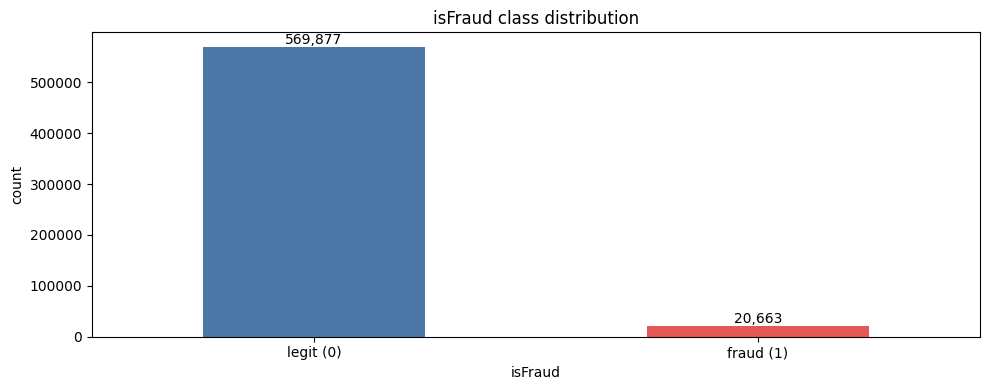

In [7]:
fig, ax = plt.subplots()
fraud_counts.plot(kind="bar", ax=ax, color=["#4c78a8", "#e45756"])
ax.set_xticklabels(["legit (0)", "fraud (1)"], rotation=0)
ax.set_ylabel("count")
ax.set_title("isFraud class distribution")
for i, v in enumerate(fraud_counts):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

### 1.4 `TransactionDT` distribution

`TransactionDT` is the number of seconds elapsed from a reference timestamp (not an absolute date). Inspect the dataset's time span and how fraud rate evolves over time.

In [8]:
dt = df_txn["TransactionDT"]
span_days = (dt.max() - dt.min()) / (60 * 60 * 24)
print(f"TransactionDT min : {dt.min():,}")
print(f"TransactionDT max : {dt.max():,}")
print(f"approx. span      : {span_days:.1f} days")
dt.describe()

TransactionDT min : 86,400
TransactionDT max : 15,811,131
approx. span      : 182.0 days


count    5.905400e+05
mean     7.372311e+06
std      4.617224e+06
min      8.640000e+04
25%      3.027058e+06
50%      7.306528e+06
75%      1.124662e+07
max      1.581113e+07
Name: TransactionDT, dtype: float64

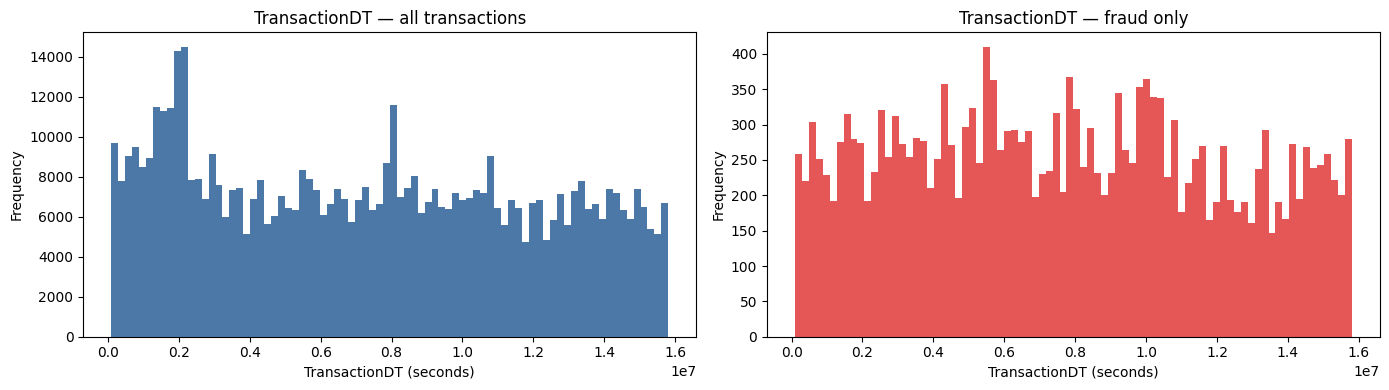

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_txn["TransactionDT"].plot(kind="hist", bins=80, ax=axes[0], color="#4c78a8")
axes[0].set_title("TransactionDT — all transactions")
axes[0].set_xlabel("TransactionDT (seconds)")

df_txn.loc[df_txn["isFraud"] == 1, "TransactionDT"].plot(
    kind="hist", bins=80, ax=axes[1], color="#e45756"
)
axes[1].set_title("TransactionDT — fraud only")
axes[1].set_xlabel("TransactionDT (seconds)")

plt.tight_layout()
plt.show()

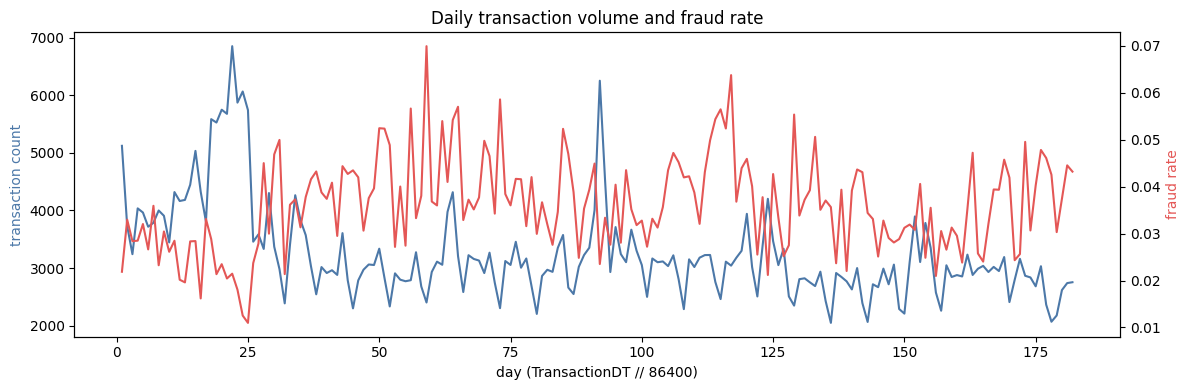

In [10]:
day_bucket = (df_txn["TransactionDT"] // (60 * 60 * 24)).astype(int)
daily = (
    df_txn.assign(day=day_bucket)
    .groupby("day")["isFraud"]
    .agg(["count", "mean"])
    .rename(columns={"count": "n_txn", "mean": "fraud_rate"})
)

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(daily.index, daily["n_txn"], color="#4c78a8", label="daily transactions")
ax1.set_ylabel("transaction count", color="#4c78a8")
ax1.set_xlabel("day (TransactionDT // 86400)")

ax2 = ax1.twinx()
ax2.plot(daily.index, daily["fraud_rate"], color="#e45756", label="fraud rate")
ax2.set_ylabel("fraud rate", color="#e45756")

plt.title("Daily transaction volume and fraud rate")
plt.tight_layout()
plt.show()

### 1.5 Summary — column count after this step

No columns dropped yet; this cell starts a counter that stays consistent across later steps.

In [11]:
n_cols_txn = df_txn.shape[1]
n_cols_id = df_id.shape[1]
print(f"[end of step 1] transaction column count = {n_cols_txn}")
print(f"[end of step 1] identity column count    = {n_cols_id}")
print(f"[end of step 1] total (post-join upper bound) = {n_cols_txn + n_cols_id - 1}  # TransactionID once")

[end of step 1] transaction column count = 394
[end of step 1] identity column count    = 41
[end of step 1] total (post-join upper bound) = 434  # TransactionID once


## 2. Memory optimization

Downcast numeric columns to shrink the in-memory footprint before the heavier EDA steps. Uses 
`reduce_mem_usage` from the project package so the same logic is shared between the notebook and 
the training pipeline.

In [3]:
import sys
from pathlib import Path

src_path = str(Path("../src").resolve())
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from fraudlens.ml.preprocessor import reduce_mem_usage  # noqa: E402

In [4]:
before_mb = (
    df_txn.memory_usage(deep=True).sum() + df_id.memory_usage(deep=True).sum()
) / 1024**2

df_txn = reduce_mem_usage(df_txn, verbose=True)
df_id = reduce_mem_usage(df_id, verbose=True)

after_mb = (
    df_txn.memory_usage(deep=True).sum() + df_id.memory_usage(deep=True).sum()
) / 1024**2

print()
print(f"combined before : {before_mb:>8.2f} MB")
print(f"combined after  : {after_mb:>8.2f} MB")
print(f"saved           : {before_mb - after_mb:>8.2f} MB ({(1 - after_mb/before_mb) * 100:.1f}%)")

2026-04-21 04:23:49 [info     ] reduce_mem_usage               after_mb=np.float64(1241.85) before_mb=np.float64(2100.7) n_cols=394 n_rows=590540 saved_mb=np.float64(858.85) saved_pct=np.float64(40.88)
2026-04-21 04:23:50 [info     ] reduce_mem_usage               after_mb=np.float64(144.43) before_mb=np.float64(157.63) n_cols=41 n_rows=144233 saved_mb=np.float64(13.2) saved_pct=np.float64(8.38)

combined before :  2258.34 MB
combined after  :  1386.28 MB
saved           :   872.06 MB (38.6%)


In [5]:
dtype_summary = (
    df_txn.dtypes.value_counts().rename("transaction")
    .to_frame()
    .join(df_id.dtypes.value_counts().rename("identity"), how="outer")
    .fillna(0)
    .astype(int)
)
dtype_summary

,transaction,identity
int8,1,0
int16,1,0
float32,376,23
int32,2,1
object,14,17


### 2.1 Column count after this step

Memory optimization does not drop columns; only dtypes change.

In [6]:
print(f"[end of step 2] transaction column count = {df_txn.shape[1]}")
print(f"[end of step 2] identity column count    = {df_id.shape[1]}")

[end of step 2] transaction column count = 394
[end of step 2] identity column count    = 41


## 3. Join transaction + identity

In [5]:
from fraudlens.ml.preprocessor import join_transaction_identity  

In [6]:
df = join_transaction_identity(df_txn, df_id, verbose=True)

print(f"joined shape           : {df.shape}")
print(f"fraud rate             : {df['isFraud'].mean():.4%}")
print(f"identity match rate    : {df_id['TransactionID'].isin(df_txn['TransactionID']).mean():.4%}")

2026-04-21 04:23:52 [info     ] join_transaction_identity      fraud_rate=0.03499 identity_match_rate=np.float64(0.244239) identity_matched=144233 n_cols=434 n_rows=590540 shape=[590540, 434]
joined shape           : (590540, 434)
fraud rate             : 3.4990%
identity match rate    : 100.0000%


In [8]:
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,NaN,NaN,NaN,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [9]:
# Sanity check: identity columns should be NaN for unmatched transactions
identity_cols = [c for c in df_id.columns if c != "TransactionID"]
unmatched_rate = df[identity_cols[0]].isna().mean()
print(f"{identity_cols[0]} NaN rate = {unmatched_rate:.4%}  (expected ~= 1 - match rate)")

id_01 NaN rate = 75.5761%  (expected ~= 1 - match rate)


### 3.1 Column count after this step

Joined frame = transaction columns + identity columns − 1 (shared `TransactionID`).

In [10]:
print(f"[end of step 3] joined column count = {df.shape[1]}")
print(f"[end of step 3] joined row count    = {df.shape[0]:,}")

[end of step 3] joined column count = 434
[end of step 3] joined row count    = 590,540


## 4. Missing-value analysis (test)

Test `handle_missing_values` on the joined frame **without overwriting raw data**. Output goes into a fresh `df_test` variable so upstream `df` / `df_txn` / `df_id` frames stay intact for later steps.

In [7]:
from fraudlens.ml.preprocessor import handle_missing_values  # noqa: E402

### 4.1 Quick overview of missing rates

In [8]:
missing_rates_preview = df.isna().mean().sort_values(ascending=False)

n_any_missing = int((missing_rates_preview > 0).sum())
n_above_5pct  = int((missing_rates_preview > 0.05).sum())
n_above_90pct = int((missing_rates_preview > 0.90).sum())

print(f"columns with any NaN   : {n_any_missing}")
print(f"columns with > 5% NaN  : {n_above_5pct}")
print(f"columns with > 90% NaN : {n_above_90pct}")

missing_rates_preview.head(15)

columns with any NaN   : 414
columns with > 5% NaN  : 322
columns with > 90% NaN : 12


id_24    0.991962
id_25    0.991310
id_07    0.991271
id_08    0.991271
id_21    0.991264
id_26    0.991257
id_27    0.991247
id_23    0.991247
id_22    0.991247
dist2    0.936284
D7       0.934099
id_18    0.923607
D13      0.895093
D14      0.894695
D12      0.890410
dtype: float64

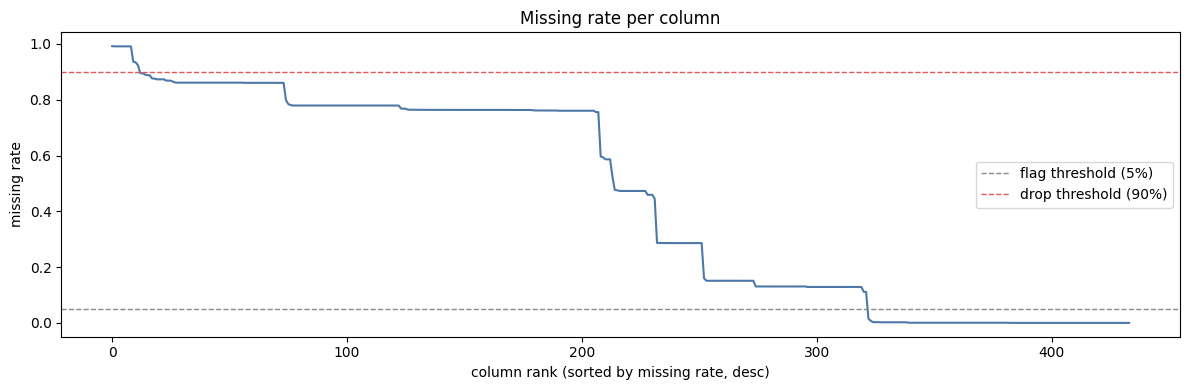

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))
missing_rates_preview.reset_index(drop=True).plot(ax=ax, color="#4c78a8")
ax.axhline(0.05, color="#888", linestyle="--", linewidth=1, label="flag threshold (5%)")
ax.axhline(0.90, color="#e45756", linestyle="--", linewidth=1, label="drop threshold (90%)")
ax.set_xlabel("column rank (sorted by missing rate, desc)")
ax.set_ylabel("missing rate")
ax.set_title("Missing rate per column")
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 Apply `handle_missing_values` (non-destructive)

In [9]:
df_test, missing_report = handle_missing_values(
    df,
    drop_threshold=0.90,
    flag_threshold=0.05,
    verbose=True,
)

print(f"input  shape : {df.shape}")
print(f"output shape : {df_test.shape}")
print(f"dropped cols : {len(missing_report.dropped_columns)}")
print(f"flag cols    : {len(missing_report.flag_columns)}")

2026-04-21 04:24:01 [info     ] handle_missing_values          drop_threshold=0.9 flag_threshold=0.05 input_cols=434 n_dropped=12 n_flags=322 output_cols=744 top_missing=[{'col': 'id_24', 'rate': 0.992}, {'col': 'id_25', 'rate': 0.9913}, {'col': 'id_07', 'rate': 0.9913}, {'col': 'id_08', 'rate': 0.9913}, {'col': 'id_21', 'rate': 0.9913}]
input  shape : (590540, 434)
output shape : (590540, 744)
dropped cols : 12
flag cols    : 322


### 4.3 Inspect dropped and flag column lists

In [15]:
print("first 20 dropped columns (sorted by missing rate):")
dropped_series = missing_report.missing_rates.loc[missing_report.dropped_columns]
dropped_series.sort_values(ascending=False).head(20)

first 20 dropped columns (sorted by missing rate):


id_24    0.991962
id_25    0.991310
id_08    0.991271
id_07    0.991271
id_21    0.991264
id_26    0.991257
id_22    0.991247
id_23    0.991247
id_27    0.991247
dist2    0.936284
D7       0.934099
id_18    0.923607
dtype: float64

In [16]:
print(f"first 10 flag columns (of {len(missing_report.flag_columns)}):")
missing_report.flag_columns[:10]

first 10 flag columns (of 322):


['addr1_is_null',
 'addr2_is_null',
 'dist1_is_null',
 'dist2_is_null',
 'P_emaildomain_is_null',
 'R_emaildomain_is_null',
 'D2_is_null',
 'D3_is_null',
 'D4_is_null',
 'D5_is_null']

In [17]:
# Sanity: flag dtype is int8 and the rate matches the source NaN rate
sample_flag = missing_report.flag_columns[0]
source_col  = sample_flag.removesuffix("_is_null")
print(f"flag column     : {sample_flag}")
print(f"flag dtype      : {df_test[sample_flag].dtype}")
print(f"flag mean (1s)  : {df_test[sample_flag].mean():.4f}")
if source_col in df.columns:
    print(f"source NaN rate : {df[source_col].isna().mean():.4f}")

flag column     : addr1_is_null
flag dtype      : int8
flag mean (1s)  : 0.1113
source NaN rate : 0.1113


### 4.4 Confirm raw frames are untouched

In [18]:
print(f"df shape     : {df.shape}  (unchanged)")
print(f"df_txn shape : {df_txn.shape}  (unchanged)")
print(f"df_id shape  : {df_id.shape}  (unchanged)")

df shape     : (590540, 434)  (unchanged)
df_txn shape : (590540, 394)  (unchanged)
df_id shape  : (144233, 41)  (unchanged)


### 4.5 Column count after this step

Net change = (flag columns added) - (columns dropped).

In [19]:
print(f"[end of step 4] df_test column count = {df_test.shape[1]}")
print(f"[end of step 4] net change           = {df_test.shape[1] - df.shape[1]:+d}")

[end of step 4] df_test column count = 744
[end of step 4] net change           = +310


### 5. Variance Test

In [19]:
from fraudlens.ml.preprocessor import drop_low_variance_features

In [20]:
df_var_reduced, dropped_var_cols = drop_low_variance_features(
    df_test, 
    frequency_threshold=0.99, 
    export_path="../data/processed/drop_variance.json"
)

2026-04-21 04:35:34 [info     ] Starting variance analysis...  initial_cols=744
2026-04-21 04:35:38 [info     ] Variance analysis completed    dropped_count=24 remaining_cols=720 threshold=0.99


In [21]:
print(f"Dropped due to low variance: {len(dropped_var_cols)}")

Dropped due to low variance: 24


### 6. V-feature Grouping

In [22]:
from fraudlens.ml.preprocessor import reduce_v_features

In [23]:
df_v_reduced, v_dropped = reduce_v_features(
    df_var_reduced, 
    keep_n=2, 
    export_path="../data/processed/v_feature_reduction.json"
)

2026-04-21 04:36:26 [info     ] Starting V-feature reduction... keep_per_group=2
2026-04-21 04:36:29 [info     ] V-feature reduction completed  dropped_count=295 groups_identified=15 initial_v_cols=325 kept_count=30


In [24]:
print(f"Total columns before : {df_test.shape[1]}")
print(f"Total columns after  : {df_v_reduced.shape[1]}")
print(f"V-features dropped   : {len(v_dropped)}")

Total columns before : 744
Total columns after  : 425
V-features dropped   : 295


In [25]:
import json
with open("../data/processed/v_feature_reduction.json", "r") as f:
    v_state = json.load(f)

print(f"\nIdentified unique NaN blocks (Groups) : {v_state['groups_found']}")
print(f"V-features kept for training        : {len(v_state['kept_v_cols'])}")


Identified unique NaN blocks (Groups) : 15
V-features kept for training        : 30


### 7. D-feature Normalization

In [26]:
from fraudlens.ml.preprocessor import normalize_d_features

In [27]:
df_d_normalized = normalize_d_features(df_v_reduced)

2026-04-21 04:38:44 [info     ] Starting D-feature normalization...
2026-04-21 04:38:44 [info     ] D-feature normalization completed features_normalized=14


In [28]:
print(f"Total columns before : {df_v_reduced.shape[1]}")
print(f"Total columns after  : {df_d_normalized.shape[1]}")

if 'D1' in df_d_normalized.columns and 'D1_norm' in df_d_normalized.columns:
    print("\nSample check for D1:")
    print(df_d_normalized[['TransactionDT', 'D1', 'D1_norm']].head(3))

Total columns before : 439
Total columns after  : 439

Sample check for D1:
   TransactionDT    D1  D1_norm
0          86400  14.0    -13.0
1          86401   0.0      1.0
2          86469   0.0      1.0


 ### 8. Create UID Features

In [29]:
from fraudlens.ml.preprocessor import create_uid_feature

In [38]:
df_uid_added = create_uid_feature(df_d_normalized)

2026-04-21 04:50:58 [info     ] Starting UID creation...      
2026-04-21 04:50:58 [info     ] UID creation completed         total_rows=590540 unique_uids=273919


In [31]:
print("--- UID Creation Test ---")
print(df_uid_added[['card1', 'addr1', 'P_emaildomain', 'uid']].head(5))

--- UID Creation Test ---
   card1  addr1 P_emaildomain                           uid
0  13926  315.0           NaN         13926_315.0_NaN_-13.0
1   2755  325.0     gmail.com      2755_325.0_gmail.com_1.0
2   4663  330.0   outlook.com    4663_330.0_outlook.com_1.0
3  18132  476.0     yahoo.com  18132_476.0_yahoo.com_-111.0
4   4497  420.0     gmail.com      4497_420.0_gmail.com_1.0


### 9. Feature Aggregate

In [51]:
from fraudlens.ml.preprocessor import apply_scaled_aggregations

In [55]:
df_agg_scaled, step_9_features = apply_scaled_aggregations(
    df_uid_added, 
    export_path="../data/processed/aggregation_rules.json"
)

2026-04-21 05:26:17 [info     ] Starting aggregation matrix   
2026-04-21 05:26:41 [info     ] Aggregation completed          added_features=74


In [56]:
df_agg_scaled = df_agg_scaled.copy()

In [57]:
print(f"--- Step 9: Scaled Aggregations Audit ---")
print(f"Total new features added : {len(step_9_features)}")
print(f"Current DataFrame shape  : {df_agg_scaled.shape}")

--- Step 9: Scaled Aggregations Audit ---
Total new features added : 74
Current DataFrame shape  : (590540, 611)


In [58]:
print("\nSample of newly created features:")
for feat in step_9_features[:15]:
    non_null = df_agg_scaled[feat].count()
    print(f"- {feat:<35} | Non-Null: {non_null}")


Sample of newly created features:
- card1_TransactionAmt_mean           | Non-Null: card1_TransactionAmt_mean    590540
card1_TransactionAmt_mean    590540
dtype: int64
- card1_TransactionAmt_std            | Non-Null: card1_TransactionAmt_std    587096
card1_TransactionAmt_std    587096
dtype: int64
- card1_TransactionAmt_max            | Non-Null: card1_TransactionAmt_max    590540
card1_TransactionAmt_max    590540
dtype: int64
- card1_TransactionAmt_min            | Non-Null: card1_TransactionAmt_min    590540
card1_TransactionAmt_min    590540
dtype: int64
- card1_TransactionAmt_median         | Non-Null: card1_TransactionAmt_median    590540
card1_TransactionAmt_median    590540
dtype: int64
- card1_D1_mean                       | Non-Null: card1_D1_mean    590520
card1_D1_mean    590520
dtype: int64
- card1_D1_std                        | Non-Null: card1_D1_std    587068
card1_D1_std    587068
dtype: int64
- card1_D1_nunique                    | Non-Null: card1_D1_nunique    59

In [59]:
amt_means = [f for f in step_9_features if 'TransactionAmt_mean' in f]
if amt_means:
    print("\nStatistical summary for key Amount means:")
    print(df_agg_scaled[amt_means[:5]].describe().loc[['mean', 'std', 'max']])


Statistical summary for key Amount means:
      card1_TransactionAmt_mean  card1_TransactionAmt_mean  card2_TransactionAmt_mean  card2_TransactionAmt_mean  card3_TransactionAmt_mean  \
mean                 135.027177                 135.027177                 134.576415                 134.576415                 134.973758   
std                   79.283324                  79.283324                  49.901916                  49.901916                  32.421561   
max                 3454.949951                3454.949951                 348.944275                 348.944275                 761.000000   

      card3_TransactionAmt_mean  card5_TransactionAmt_mean  card5_TransactionAmt_mean  uid_TransactionAmt_mean  uid_TransactionAmt_mean  
mean                 134.973758                 134.747203                 134.747203               135.027176               135.027176  
std                   32.421561                  38.445659                  38.445659               219.5874

### 10. Relative & domain features

In [61]:
from fraudlens.ml.preprocessor import apply_relative_and_domain_features

In [66]:
df_rel_added, step_10_new_cols = apply_relative_and_domain_features(
    df_agg_scaled, 
    export_path="../data/processed/domain_rules.json"
)

2026-04-21 05:29:55 [info     ] Starting feature engineering (defragmented)...
2026-04-21 05:29:56 [info     ] Industry-standard features completed added_count=17 final_cols=554


In [67]:
print(f"--- Step 10: Feature Quality Audit ---")
print(f"New features added: {len(step_10_new_cols)}")

--- Step 10: Feature Quality Audit ---
New features added: 17


In [72]:
stats_df = df_rel_added[step_10_new_cols].agg(['mean', 'std', 'max', 'min']).T
stats_df['nan_count'] = df_rel_added[step_10_new_cols].isna().sum()

print("\nStatistical Summary for Step 10 Features:")
print(stats_df)


Statistical Summary for Step 10 Features:
                                   mean         std         max         min  nan_count
amt_zscore_uid                 0.015024    1.543046  122.070312 -122.070312     177503
amt_to_mean_uid                1.000000    0.394564   14.485569    0.007645          0
amt_to_median_uid              1.104589    0.982542  133.687051    0.007591          0
amt_to_mean_card1              1.000000    1.366219  114.123904    0.002787          0
amt_to_median_card1            1.700549    2.658849  285.155271    0.004570          0
amt_to_mean_card2              1.000000    1.523345  140.447672    0.002071       8933
amt_to_median_card2            1.757242    2.809923  295.853555    0.004003       8933
amt_to_mean_addr1              1.000000    1.704709  243.026314    0.006022      65706
amt_to_median_addr1            1.807171    3.103946  431.878181    0.010000      65706
amt_to_mean_ProductCD          1.000000    1.583849  208.525019    0.005855          0


In [71]:
print(f"\nFinal DataFrame Shape: {df_rel_added.shape}")


Final DataFrame Shape: (590540, 537)


In [70]:
# Mükerrer kolonları isim bazında temizle
df_rel_added = df_rel_added.loc[:, ~df_rel_added.columns.duplicated(keep='first')]

# Defragmentation (Bellek hizalama)
df_rel_added = df_rel_added.copy()

print(f"Unique columns check: {df_rel_added.columns.is_unique}") # True dönmeli

Unique columns check: True
